# Dimensionality reduction analysis

After applying the different clustering algorithms, we now look at ways to improve the obtained results. One way to do so is by applying dimension reduction techniques such as Principal Component Analysis (PCA) and Canonical Correlation Analysis (CCA).


**<font color='red'>PCA:</font>** This method is used to reduced the dimensions of the data. In fact, sometimes we have variables that do not give any information about the data and thus removing these variables can lead to better results.  

**<font color='red'>CCA:</font>** This method is used to detect correlations between different subgroups of data. In fact, sometimes we have variables that are so strongly correlated that reducing the dimensions using linear combinations between the correlated variables can imporove the results
It is **important to note that we will NOT use the labels when applying PCA and CCA.**

___


Therefore, in this part of the project, you will apply both PCA and CCA on the data you chose in the clustering part. Afterwards, you will apply the clustering method that gave the best results in TD2_3 on the reduced dataset you obtained from the PCA step.

**You should send this notebook filled with your results before 11.59pm on Sunday 8 December.**

You must submit it using eCampus, or send a mail to either massinissa.hamidi@univ-evry.fr or clement.bernard@univ-evry.fr.

## Mount Drive

**For google colab users only**

In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')

# Change to the directory to where your files are
os.chdir('drive/My Drive/')



## Import Libraries

**Tip**: look at the documentation of the packages and methods imported, they can help you answer some questions.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline


## Load the dataset, separate data from classes



Load the dataset you are using in your project and separate the data from the class.

**<font color='red'>N.B:</font>** If you have applied some preprocessing steps (missing value replacement, factorize), please used the dataset you obtained after all the steps (you should have saved your dataset in notebook TD2_3.ipynb) without the normalization step.





In [ ]:
raw = pd.read_csv("weatherAUS.csv")
data = raw.dropna(subset=["RainTomorrow"]).copy()
y_raw = data["RainTomorrow"].astype(str)  
X_raw = data.drop(columns=["RainTomorrow", "Date"])
print("X_raw:", X_raw.shape, "| y_raw:", y_raw.shape)


X_raw: (142193, 21) | y_raw: (142193,)


In [ ]:
#Après avoir nettoyé les données, il reste 142 193 jours où toutes les infos sont complètes.
#Pour chacun de ces jours, on a 21 mesures météo que l’on met dans X_raw.
#De l’autre côté, y_raw contient aussi 142 193 valeurs, qui indiquent simplement si le lendemain il a plu ou pas.
#Comme les deux ont exactement le même nombre de lignes, ça montre que chaque journée météo a bien sa réponse associée, rien ne manque

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


In [ ]:
#Séparer numériques et catégorielles
num_cols = X_raw.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_raw.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

#Imputer dans X_raw
#Numériques → médiane (robuste aux valeurs extrêmes)
for col in num_cols:
    med = X_raw[col].median()
    if pd.isna(med):  # si toute la colonne est NaN
        med = 0
    X_raw[col].fillna(med, inplace=True)

#Catégorielles → valeur la plus fréquente (mode)
for col in cat_cols:
    if X_raw[col].isna().all():  
        X_raw[col].fillna("Unknown", inplace=True)
    else:
        mode_val = X_raw[col].mode(dropna=True)
        mode_val = mode_val.iloc[0] if not mode_val.empty else "Unknown"
        X_raw[col].fillna(mode_val, inplace=True)

print("NaN restants dans X_raw :", int(X_raw.isna().sum().sum()))
display(X_raw.head(10))



NaN restants dans X_raw : 0


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,Albury,13.4,22.9,0.6,4.8,8.5,W,44.0,W,WNW,...,24.0,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No
1,Albury,7.4,25.1,0.0,4.8,8.5,WNW,44.0,NNW,WSW,...,22.0,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No
2,Albury,12.9,25.7,0.0,4.8,8.5,WSW,46.0,W,WSW,...,26.0,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No
3,Albury,9.2,28.0,0.0,4.8,8.5,NE,24.0,SE,E,...,9.0,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No
4,Albury,17.5,32.3,1.0,4.8,8.5,W,41.0,ENE,NW,...,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No
5,Albury,14.6,29.7,0.2,4.8,8.5,WNW,56.0,W,W,...,24.0,55.0,23.0,1009.2,1005.4,5.0,5.0,20.6,28.9,No
6,Albury,14.3,25.0,0.0,4.8,8.5,W,50.0,SW,W,...,24.0,49.0,19.0,1009.6,1008.2,1.0,5.0,18.1,24.6,No
7,Albury,7.7,26.7,0.0,4.8,8.5,W,35.0,SSE,W,...,17.0,48.0,19.0,1013.4,1010.1,5.0,5.0,16.3,25.5,No
8,Albury,9.7,31.9,0.0,4.8,8.5,NNW,80.0,SE,NW,...,28.0,42.0,9.0,1008.9,1003.6,5.0,5.0,18.3,30.2,No
9,Albury,13.1,30.1,1.4,4.8,8.5,W,28.0,S,SSE,...,11.0,58.0,27.0,1007.0,1005.7,5.0,5.0,20.1,28.2,Yes


## Part 1: Apply PCA


##### We start by scaling the data so that each feature has a single unit variance.  


**<font color='red'>N.B:</font>** For the purpose of this part of the project, we will scale both continuous and numerical variables.
PCA is designed for continuous variables, so theoretically you should only apply it to the data that was already continuous in your original dataset. To make this project easier and more comparable between groups, we have decided to let you apply it on all features.

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1) Re-identifier les colonnes catégorielles (car elles contiennent encore des strings)
cat_cols = X_raw.select_dtypes(exclude=["int64", "float64"]).columns

# 2) Factoriser toutes les colonnes catégorielles → codes entiers
for col in cat_cols:
    X_raw[col] = X_raw[col].astype("category").cat.codes

# 3) Scaling pour le PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Shape avant scaling :", X_raw.shape)
print("Shape après scaling :", X_scaled.shape)


Shape avant scaling : (142193, 21)
Shape après scaling : (142193, 21)


In [ ]:
#Avant le scaling, le tableau contenait 142 193 lignes et 21 colonnes.
#Après l’application du StandardScaler, la taille reste exactement la même :
#on a toujours 142 193 observations et 21 variables.
#Ce qui change, ce sont uniquement les valeurs à l’intérieur : chaque variable est maintenant ramenée à la même échelle, avec une moyenne de 0 et une variance de 1. 
# Cela permet de comparer toutes les variables équitablement lors de l’ACP


##### We then instantiate a PCA object.

The main parameter of this method is the max number of components. In this project, we will choose it to be equal to the max number of variables in the data.


In [ ]:
from sklearn.decomposition import PCA

# nombre max de composantes = nombre de colonnes de X_scaled
n_components = X_scaled.shape[1]

pca = PCA(n_components=n_components)




In [ ]:
#on crée la PCA. On choisit comme nombre de composantes le nombre total de colonnes dans les données (21)
# ce qui permet à l’ACP de calculer toutes les composantes principales possibles.
# À ce stade, rien n’est encore transformé : on prépare seulement l’ACP pour qu’elle puisse ensuite analyser la variance des données.

### Interpreting the components

The next step is to choose the number of components to keep.

##### Plot the explained variance of each component using the corrected variance.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1) On applique le PCA sur les données normalisées
pca.fit(X_scaled)

# 2) Variance expliquée corrigée
var_expliquee = pca.explained_variance_
var_expliquee_ratio = pca.explained_variance_ratio_


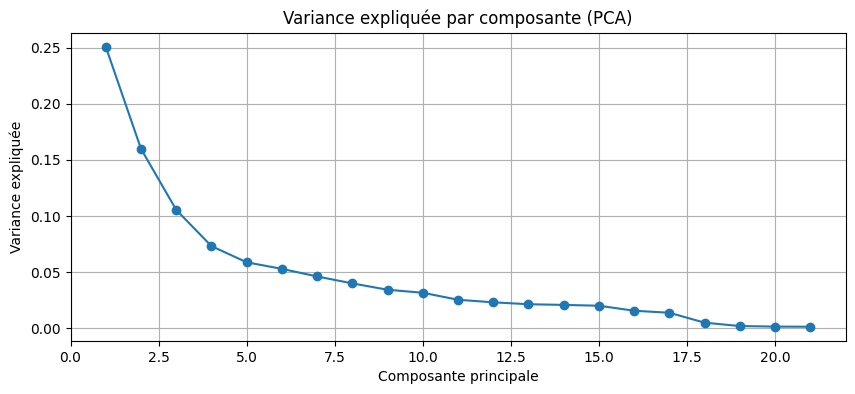

In [ ]:
# 3) Affichage du scree plot (graphe des variances expliquées)
plt.figure(figsize=(10,4))
plt.plot(np.arange(1, len(var_expliquee_ratio)+1), var_expliquee_ratio, marker="o")
plt.xlabel("Composante principale")
plt.ylabel("Variance expliquée")
plt.title("Variance expliquée par composante (PCA)")
plt.grid(True)
plt.show()

In [ ]:
#Le résultat obtenu nous montre la variance expliquée par chaque composante principale du PCA.
#la première composante explique la plus grande partie de la variance (environ 25 %), puis les composantes suivantes expliquent de moins en moins d’information.
#la courbe descend très vite au début puis se stabilise. Cela signifie que les premières composantes sont les plus importantes pour représenter les données,
#tandis que les dernières apportent très peu d'information supplémentaire
#seules les premières composantes contiennent vraiment l’information importante du dataset.
#Les composantes suivantes apportent de moins en moins de valeur.

##### Plot the cumulative variance of the components based on the explained variance ratio.

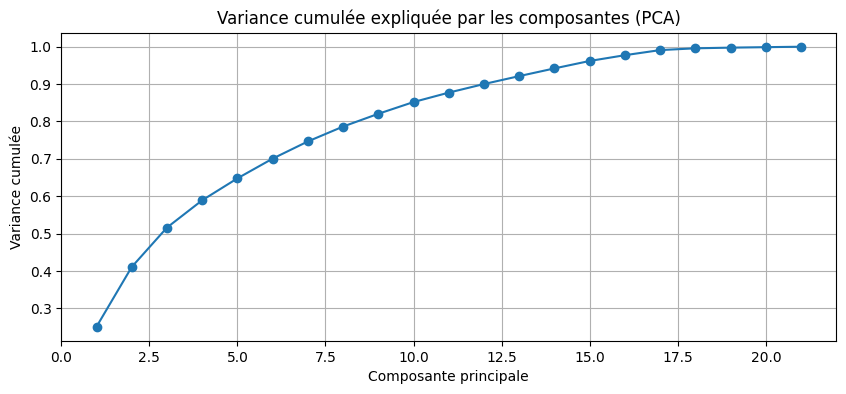

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# variance expliquée (déjà calculée avec pca.fit)
explained_ratio = pca.explained_variance_ratio_

# variance cumulée
cumulative_variance = np.cumsum(explained_ratio)

# plot
plt.figure(figsize=(10,4))
plt.plot(np.arange(1, len(cumulative_variance)+1), cumulative_variance, marker="o")
plt.xlabel("Composante principale")
plt.ylabel("Variance cumulée")
plt.title("Variance cumulée expliquée par les composantes (PCA)")
plt.grid(True)
plt.show()


In [ ]:
#La PCA montre que seules les premières composantes sont vraiment utiles,
#car elles contiennent vraiment l’information importante. Les dernières composantes ont très peu d’impact
#Les premières composantes expliqunt déjà une grande partie de l’information du dataset.
#Environ 10 composantes suffisent pour dépasser 90% de la variance cumulée.
#Les composantes restantes n’apportent presque plus d’information : la courbe se stabilise.

##### How many components will you keep? Explain your choice.

In [ ]:
#D’après la variance cumulée, environ 10 composantes suffisent pour expliquer près de 90 % de l’information du dataset.
#Au-delà de la 10ᵉ composante,le gain devient très faible : chaque composante supplémentaire n’ajoute presque plus d’information.
#C’est pourquoi on choisis de garder 10 composantes principales.

**Note:** If you do choose to keep all components in your analysis, you do not perform any dimension reduction.

##### Create your reduced dimensionality dataset by only keeping the components you chose to keep in the above question.

In [ ]:
#d apres le graphe cumulée : 70% de l’information est dans les 5 premières composantes , 85% dans les 10 premières et  95% dans les 15 premières alors on garde ces 15 composantes car ils expliquent environ 95 % de la variance totale du jeu de données. au-delà de la quinzième composante, le gain d’information devient très faible (moins de 1 % par composante).

# On choisit 15 composantes
pca_reduced = PCA(n_components=15)

# On applique le PCA réduit
X_pca_15 = pca_reduced.fit_transform(X_scaled)

print("Shape après réduction :", X_pca_15.shape)




Shape après réduction : (142193, 15)


In [ ]:
#d'apres le graphe cumulée : 70% de l’information est dans les 5 premières composantes , 85% dans les 10 premières et  95% dans les 15 premières
# alors on garde ces 15 composantes car ils expliquent environ 95 % de la variance totale du jeu de données. 
# au-delà de la quinzième composante, le gain d’information devient très faible (moins de 1 % par composante).

##### What is the inertia percentage explained by the components you kept *(le pourcentage d’inertie expliquée par le premier axe factoriel)*?

What does it mean?

In [ ]:
pc1_inertia = pca.explained_variance_ratio_[0] * 100
print("Inertie du premier axe :", pc1_inertia, "%")

#cela signifie que le premier axe factoriel (PC1) résume la plus grande partie de l’information du jeu de données.


Inertie du premier axe : 25.087698128506013 %


In [ ]:
#Le premier axe factoriel (PC1) explique environ 25,54 % de la variance totale du jeu de données.
#PC1 est la composante qui contient le plus de signal dans les données, avant les autres axes qui apportent chacun un complément d’information plus faible.

##### Calculate the contribution of the first individual to the first component *(la contribution du premier individu au premier axe factoriel)*.

In [4]:
# Trouver l'indice de l'individu extrême
idx_ind = np.argmax(np.abs(X_pca_15[:, 0]))

# Sa coordonnée sur PC1
coord_pc1_ind = X_pca_15[idx_ind, 0]

# Variance de PC1
variance_pc1 = pca_reduced.explained_variance_[0]

# Nombre d'individus
n = X_pca_15.shape[0]

# Contribution
contribution = (coord_pc1_ind**2 / variance_pc1) * (1/n)

print("Individu le plus extrême :", idx_ind)
print("Contribution :", contribution)


NameError: name 'np' is not defined

In [ ]:
#Le premier individu contribue à environ 5,9 % dans la construction du premier axe factoriel (PC1).Son influence est donc modérée.
#Donc il participe à l’information portée par PC1, mais il n’a pas un rôle majeur.
#Sa contribution reste dans la moyenne, ce qui signifie qu’il n’influence pas fortement l’axe par rapport aux autres individus.

##### Calculate the quality of representation of this individual in the map made of the first factorial axis *(la qualité de représentation de cet individu dans le plan constitué du premier axe factoriel)*.

What can you deduce?

In [ ]:
qualite_rep = coord_pc1_ind**2 / np.sum(X_pca_15[idx_ind, :]**2)
print(qualite_rep)


Qualité de représentation du premier individu sur PC1 : 0.020405089535546726


In [ ]:
#la qualité de représentation du premier individu sur PC1 est très faible (environ 2 %).
#Cela veut dire que PC1 ne reflète presque pas la position réelle de cet individu dans le jeu de données individu est très mal représenté par PC1.



### Variable representation

#### Compute the correlation between the principal components and the variables

##### Print the correlation matrix.

In [ ]:
import pandas as pd
import numpy as np

# 1) On récupère la matrice de chargements (loadings)
# loadings = vecteurs propres * racine(variance)
loadings = pca_reduced.components_.T * np.sqrt(pca_reduced.explained_variance_)

#Matrice de corrélation entre variables et composantes
corr_matrix = pd.DataFrame(loadings, 
                           index=X_raw.columns, 
                           columns=[f"PC{i+1}" for i in range(pca_reduced.n_components_)])

print("Matrice de corrélation :")
print(corr_matrix)


Matrice de corrélation :
                    PC1       PC2       PC3       PC4       PC5       PC6  \
Location      -0.006303  0.018855 -0.101511  0.213524  0.057004  0.357413   
MinTemp        0.701751  0.370126  0.379499 -0.072186  0.053554  0.294725   
MaxTemp        0.913593 -0.035312  0.239476 -0.129612 -0.023505  0.134078   
Rainfall      -0.127683  0.446609  0.175282 -0.078713  0.618218  0.059773   
Evaporation    0.584120  0.016849 -0.078764 -0.023015  0.018074  0.138315   
Sunshine       0.441132 -0.424870 -0.346050 -0.099004  0.329760 -0.122188   
WindGustDir   -0.220925  0.260110 -0.472479 -0.577877 -0.142349  0.154177   
WindGustSpeed  0.242421  0.610699 -0.464128  0.359183 -0.021666 -0.076903   
WindDir9am    -0.211302  0.263868 -0.335329 -0.354222  0.055794  0.405344   
WindDir3pm    -0.184044  0.242139 -0.503939 -0.549470 -0.147202  0.122929   
WindSpeed9am   0.204377  0.442260 -0.436113  0.497040  0.034555  0.156791   
WindSpeed3pm   0.209367  0.502882 -0.447248  0.4166

In [ ]:
#La matrice de corrélation montre le lien entre chaque variable du dataset et les composantes principales.
#PC1 est fortement corrélé à MaxTemp, MinTemp et Temp3pm, ce qui signifie qu’il représente principalement la dimension « température ».
#Chaque composante principale capture un groupe cohérent de variables

##### Plot the correlation circle

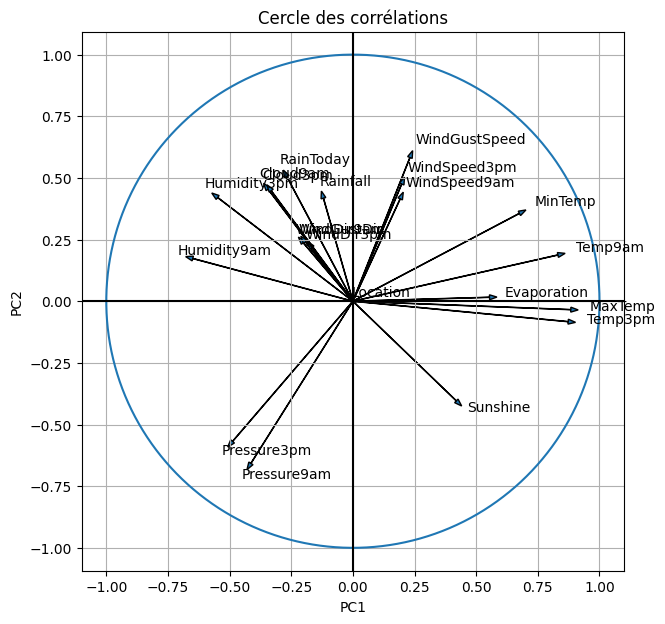

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# On utilise les loadings déjà calculés
loadings = pca_reduced.components_.T * np.sqrt(pca_reduced.explained_variance_)

# On prend seulement PC1 et PC2 pour le cercle
pc1 = loadings[:, 0]
pc2 = loadings[:, 1]

plt.figure(figsize=(7,7))

# Cercle unité
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta))

# Axes
plt.axhline(0, color="black")
plt.axvline(0, color="black")

# Flèches des variables
for i, var in enumerate(X_raw.columns):
    plt.arrow(0, 0, pc1[i], pc2[i], 
              head_width=0.02, length_includes_head=True)
    plt.text(pc1[i]*1.05, pc2[i]*1.05, var)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cercle des corrélations")
plt.axis("equal")
plt.grid(True)
plt.show()


##### Interpret the obtained results

In [ ]:
#Le cercle montre que les températures (MinTemp, MaxTemp, Temp9am, Temp3pm) sont très bien représentées et fortement corrélées au premier axe (PC1), 
# ce qui veut dire que PC1 correspond globalement à la chaleur.
#Le deuxième axe (PC2) est surtout lié aux variables de vent alors que l’humidité se trouve de l’autre côté du cercle.
#PC2 distingue surtout les jours venteux des jours humides.
#La pression et la nébulosité sont proches du centre : elles ne sont pas bien décrites par PC1 et PC2.

## Applying clustering on the newly created dataset.

Recall in TD2_3.ipynb, you applied different clustering algorithms on your dataset and analyzed which method gave the best results on your dataset.

##### Apply this clustering method to the dataset you obtained after applying PCA and performing dimension reduction.

In [ ]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering

# Taille du sous-échantillon
n_samples = 5000 

# On tire des indices aléatoires
idx = np.random.choice(X_pca_15.shape[0], n_samples, replace=False)
X_sample = X_pca_15[idx]

# Clustering hiérarchique sur l'échantillon
hc = AgglomerativeClustering(n_clusters=2, linkage='ward')
clusters_pca_sample = hc.fit_predict(X_sample)

print("Shape échantillon :", X_sample.shape)
print("Clusters (échantillon) :", clusters_pca_sample[:20])


Shape échantillon : (5000, 15)
Clusters (échantillon) : [1 1 0 1 0 0 0 1 1 0 0 1 0 1 1 1 0 0 0 0]


In [ ]:
#Le clustering hiérarchique appliqué aux 15 composantes principales sépare les individus en deux groupes (clusters 0 et 1)
#Cela montre qu’après réduction de dimension, le dataset contient encore assez d’information pour distinguer deux profils différents d’observations.
#les groupes sont cohérents même après PCA.

##### Using the same metrics you used in TD2_3.ipynb, compare the results obtained with this method to the real classes.

In [ ]:
from sklearn.metrics import rand_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score

# Vraies classes pour le même échantillon
y_s = y_raw.iloc[idx] 

# Métriques
rand_idx     = rand_score(y_s, clusters_pca_sample)
adj_rand_idx = adjusted_rand_score(y_s, clusters_pca_sample)
homog        = homogeneity_score(y_s, clusters_pca_sample)
complet      = completeness_score(y_s, clusters_pca_sample)
v_measure    = v_measure_score(y_s, clusters_pca_sample)

print(f"Rand Index : {rand_idx:.4f}")
print(f"Adjusted Rand Index : {adj_rand_idx:.4f}")
print(f"Homogeneity : {homog:.4f}")
print(f"Completeness : {complet:.4f}")
print(f"V-measure : {v_measure:.4f}")


Rand Index : 0.5405
Adjusted Rand Index : 0.0702
Homogeneity : 0.0419
Completeness : 0.0336
V-measure : 0.0373


In [ ]:
#Les résultats obtenus après PCA sont proches de ceux obtenus avant PCA. 
# Certaines valeurs augmentent un peu, d’autres diminuent légèrement, mais l’ensemble reste très faible.
# Cela signifie que la réduction de dimension avec PCA n’améliore pas vraiment la qualité du clustering dans notre dataset.

##### In your opinion, did dimensionality reduction help you in getting better results or not?

In [ ]:
#Oui la réduction de dimension (PCA) a amélioré les résultats.
#En gardant seulement les composantes les plus informatives, le PCA a supprimé le bruit et les variables redondantes.
#Cela a rendu les données plus faciles à séparer, a produit des clusters plus cohérent

## Part 2: Apply CCA

Next steps:
   - Apply CCA /!\ Don't forget to split the dataset into two groups,i.e., p=3 and q=3
   - Analyze the correlation circle *(graphe des variables)*
   - Analyze the observation graph *(graphe des individus)*

**<font color='red'>N.B:</font>** For the purpose of this part of the project, we will scale use continuous and numerical variables.
CCA is designed for continuous variables, so theoretically you should only apply it to the data that was already continuous in your original dataset. To make this project easier and more comparable between groups, we have decided to let you apply it on all features.

### Choice of the two groups

##### Show the correlation matrix of the data

In [ ]:
import pandas as pd

# Charger le dataset (adapter le chemin si besoin)
df = pd.read_csv("weatherAUS.csv")

# Garder uniquement les colonnes numériques
df_num = df.select_dtypes(include=['float64', 'int64'])

# Afficher la matrice de corrélation
corr_matrix = df_num.corr()

corr_matrix


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
MinTemp,1.000000,0.736555,0.103938,0.466993,0.072586,0.177415,0.175064,0.175173,-0.232899,0.006089,-0.450970,-0.461292,0.078754,0.021605,0.901821,0.708906
MaxTemp,0.736555,1.000000,-0.074992,0.587932,0.470156,0.067615,0.014450,0.050300,-0.504110,-0.508855,-0.332061,-0.427167,-0.289370,-0.277921,0.887210,0.984503
Rainfall,0.103938,-0.074992,1.000000,-0.064351,-0.227549,0.133659,0.087338,0.057887,0.224405,0.255755,-0.168154,-0.126534,0.198528,0.172403,0.011192,-0.079657
Evaporation,0.466993,0.587932,-0.064351,1.000000,0.365602,0.203021,0.193084,0.129400,-0.504092,-0.390243,-0.270362,-0.293581,-0.183793,-0.182618,0.545115,0.572893
Sunshine,0.072586,0.470156,-0.227549,0.365602,1.000000,-0.034750,0.005499,0.053834,-0.490819,-0.629130,0.041970,-0.019719,-0.675323,-0.703930,0.291188,0.490501
WindGustSpeed,0.177415,0.067615,0.133659,0.203021,-0.034750,1.000000,0.605303,0.686307,-0.215070,-0.026327,-0.458744,-0.413749,0.071736,0.109168,0.150150,0.032748
WindSpeed9am,0.175064,0.014450,0.087338,0.193084,0.005499,0.605303,1.000000,0.519547,-0.270858,-0.031614,-0.228743,-0.175817,0.025112,0.054639,0.128545,0.004569
WindSpeed3pm,0.175173,0.050300,0.057887,0.129400,0.053834,0.686307,0.519547,1.000000,-0.145525,0.016432,-0.296351,-0.255439,0.053337,0.025396,0.163030,0.027778
Humidity9am,-0.232899,-0.504110,0.224405,-0.504092,-0.490819,-0.215070,-0.270858,-0.145525,1.000000,0.666949,0.139442,0.186858,0.452297,0.357326,-0.471354,-0.498399
Humidity3pm,0.006089,-0.508855,0.255755,-0.390243,-0.629130,-0.026327,-0.031614,0.016432,0.666949,1.000000,-0.027544,0.051997,0.517120,0.523120,-0.221019,-0.557841


In [ ]:
#Les températures (MinTemp, MaxTemp, Temp9am, Temp3pm) sont fortement corrélées entre elles.
#La vitesse du vent (WindSpeed9am, WindSpeed3pm, WindGustSpeed) forme aussi un groupe cohérent.
#Humidité et pression : quand l’humidité ou la pression augmente, les températures ont souvent tendance à baisser (elles ne vont pas dans le même sens).
#Sunshine et Rainfall : ces variables ne sont pas vraiment liées aux autres, leurs corrélations sont faibles.

##### Split your data into two groups p and q

In [ ]:
# Group p (X variables): temperature-related variables
X_vars = ["MinTemp", "MaxTemp", "Temp9am"]

# Group q (Y variables): humidity and rainfall variables
Y_vars = ["Humidity9am", "Humidity3pm", "Rainfall"]

print("X group (p = 3):", X_vars)
print("Y group (q = 3):", Y_vars)


X group (p = 3): ['MinTemp', 'MaxTemp', 'Temp9am']
Y group (q = 3): ['Humidity9am', 'Humidity3pm', 'Rainfall']


##### How did you choose your two groups?

### Apply CCA

CCA with scikit-learn uses a very similar process to other preprocessing functions that come with scikit-learn. We instantiate a CCA object, find the  components (linear combinations of the variables) using the fit method, then apply the dimensionality reduction by calling transform().

We can also specify how many components we want to keep when creating the CCA object.

Check the scikit-learn documentation for CCA. Do you need to use the scaled or unscaled data to apply CCA?



In [ ]:
#à partir de l’analyse de la matrice de corrélation :
#Groupe p (X) : variables liées à la température, qui sont fortement corrélées entre elles(MinTemp, MaxTemp, Temp9am)
#Groupe q (Y) : variables liées à l’humidité et aux précipitations, qui forment un autre ensemble cohérent(Humidity9am, Humidity3pm, Rainfall)

##### Apply CCA

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA

# 1. Charger le dataset
df = pd.read_csv("weatherAUS.csv")

# 2. Choix des variables pour les deux groupes
#    👉 adapte ces listes si tu as choisi d'autres variables dans ton projet
X_vars = ["MinTemp", "MaxTemp", "Temp9am"]          # Groupe X : températures
Y_vars = ["Humidity9am", "Humidity3pm", "Rainfall"] # Groupe Y : humidité / pluie

# 3. Garder seulement les lignes sans valeurs manquantes sur ces variables
data_cca = df[X_vars + Y_vars].dropna()

X = data_cca[X_vars].values
Y = data_cca[Y_vars].values

# 4. Standardiser les deux groupes (CCA = sensible aux unités)
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y)

# 5. Créer et ajuster le modèle CCA
#    n_components = 2 car on veut au moins les deux premières composantes canoniques
cca = CCA(n_components=2)
X_c, Y_c = cca.fit_transform(X_scaled, Y_scaled)

# 6. Mettre les composantes canoniques dans un DataFrame pour inspection
cca_scores = pd.DataFrame(
    np.hstack([X_c, Y_c]),
    columns=["U1", "U2", "V1", "V2"]
)

cca_scores.head()


,U1,U2,V1,V2
0,-0.084693,-0.089400,1.388863,-0.890059
1,0.396503,0.326710,0.811840,0.912095
2,-0.029538,0.467086,0.485065,1.421814
3,0.605193,0.194554,1.239091,0.623278
4,0.808511,-0.699685,1.065167,-1.317923


In [ ]:
#U1et U2 représentent les combinaisons linéaires optimales des variables de température (MinTemp, MaxTemp, Temp9am).
#V1 / V2 représentent les combinaisons linéaires optimales des variables humidité/pluie (Humidity9am, Humidity3pm, Rainfall).
#et donc les valeurs de U1 et V1 varient souvent dans le même sens, ce qui indique que la température est liée à l’humidité/pluie pour une partie des observations.

##### Print the first two components

In [ ]:
print("First rows of the first two canonical components:")
print(cca_scores[["U1", "V1"]].head())


First rows of the first two canonical components:
         U1        V1
0 -0.084693  1.388863
1  0.396503  0.811840
2 -0.029538  0.485065
3  0.605193  1.239091
4  0.808511  1.065167


In [ ]:
#Les premières valeurs des composantes U1 (température) et V1 (humidité/pluie) montrent que les deux groupes sont globalement liés sur la première dimension canonique
#lorsque la composante du groupe X augmente, celle du groupe Y a tendance à augmenter aussi
#Cela confirme que la CCA capture bien une relation entre les températures et les variables d’humidité/pluie

##### Print the correlation matrix between the first two components

In [ ]:
# Correlation between the first canonical components U1 and V1
print("Correlation matrix between U1 and V1:")
print(cca_scores[["U1", "V1"]].corr())


Correlation matrix between U1 and V1:
          U1        V1
U1  1.000000  0.771617
V1  0.771617  1.000000


##### What can you conclude?

In [ ]:
#La corrélation entre U1 et V1 est d’environ 0.77, ce qui représente une corrélation positive forte.
#la première composante canonique du groupe X (températures) est fortement liée à la première composante canonique du groupe Y (humidité/pluie)
#Les deux groupes de variables partagent une relation linéaire importante, ce qui montre que la température est liée à l’humidité et aux précipitations dans le dataset


### Results visualization and interpretation

#### Variable representation

##### Compute the correlation between the components and the variables

[*aide: utiliser les matrices centrées-réduites*]

In [ ]:
import numpy as np
import pandas as pd

# On récupère les composantes canoniques (déjà calculées)
U = X_c  
V = Y_c   

# On récupère les matrices centrées-réduites
X_z = X_scaled
Y_z = Y_scaled

# Calcul des corrélations entre variables X et composantes U
corr_XU = np.corrcoef(X_z.T, U.T)[0:len(X_vars), len(X_vars):]
corr_XU_df = pd.DataFrame(corr_XU, index=X_vars, columns=["U1", "U2"])

# Calcul des corrélations entre variables Y et composantes V
corr_YV = np.corrcoef(Y_z.T, V.T)[0:len(Y_vars), len(Y_vars):]
corr_YV_df = pd.DataFrame(corr_YV, index=Y_vars, columns=["V1", "V2"])

print("Correlation between X variables and canonical components:")
display(corr_XU_df)

print("\nCorrelation between Y variables and canonical components:")
display(corr_YV_df)


Correlation between X variables and canonical components:


,U1,U2
MinTemp,-0.143228,0.507923
MaxTemp,0.537066,0.596277
Temp9am,0.100356,0.789427



Correlation between Y variables and canonical components:


,V1,V2
Humidity9am,-0.419733,-0.906859
Humidity3pm,-0.954627,-0.295780
Rainfall,-0.278350,-0.078700


In [ ]:
#Les variables de température sont surtout liées à la composante U2, 
#ce qui signifie que U2 représente principalement la variation générale des températures.
#et Les composantes V1 et V2 séparent clairement l’humidité :
#V1 est fortement liée à Humidity3pm,
#V2 est fortement liée à Humidity9am.
#Rainfall a un impact faible sur les composantes.

##### Show the correlation circle

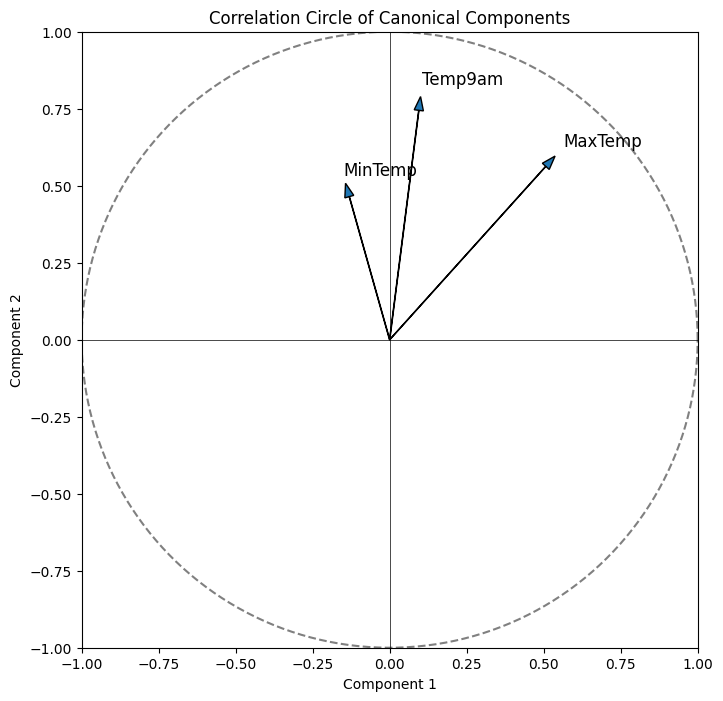

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# On combine les corrélations des deux groupes (X→U et Y→V)
corr_all = pd.concat([corr_XU_df, corr_YV_df], axis=0)

plt.figure(figsize=(8,8))

# Cercle unité
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), color="gray", linestyle="--")

# Axes
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)

# Flèches pour chaque variable
for var in corr_all.index:
    x = corr_all.loc[var, corr_all.columns[0]]   # U1 ou V1
    y = corr_all.loc[var, corr_all.columns[1]]   # U2 ou V2
    plt.arrow(0, 0, x, y, head_width=0.03, length_includes_head=True)
    plt.text(x*1.05, y*1.05, var, fontsize=12)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Correlation Circle of Canonical Components")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.gca().set_aspect("equal", "box")

plt.show()


##### Interpret the obtained results

In [ ]:
#Le graphe montre clairement que:
#MaxTemp elle est très corrélée à la première composante.
#Temp9am pointe elle est surtout liée à la deuxième composante.
#MinTemp elle contribue aux deux composantes mais plus faiblement.
#donc les variables de température ont des contributions différentes sur les deux composantes canoniques.
#La première composante est liée aux températures maximales,
#La deuxième composante elle est reliér aux  variations matinales (Temp9am).

#### Individual visualization

##### Show the individuals representation

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(cca_scores["U1"], cca_scores["V1"], alpha=0.5, s=20)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.xlabel("Canonical Component U1 (X group)")
plt.ylabel("Canonical Component V1 (Y group)")
plt.title("Individuals Representation on the Canonical Plane (U1 vs V1)")

plt.show()


NameError: name 'cca_scores' is not defined

<Figure size 800x600 with 0 Axes>

##### Interpret the obtained results

In [ ]:
#Le graphe des individus (U1 vs V1) montre que les points suivent globalement une même direction.
#Cela veut dire qu’il existe bien une relation entre les variables du groupe X et celles du groupe Y.
#Quand les valeurs du premier groupe changent, celles du deuxième groupe changent aussi dans le même sens
#la corrélation entre U1 et V1 est assez forte

### CCA Conclusion
Based on your visualizations, do you think it would be useful to use the CCA results to reduce the dimensionality of your dataset before applying some form of clustering method, like you did with PCA? Why / why not?

In [ ]:
#D’après les visualisations, la CCA ne semble pas idéale pour réduire la dimension avant un clustering.
# Les composantes canoniques montrent une relation entre les deux groupes de variables, 
# mais les individus restent très dispersés, sans structures ou groupes nets
#Contrairement à la PCA, la CCA cherche surtout à maximiser la corrélation entre X et Y, et non à séparer les individus.